In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [209]:
# =============================================================
# 1. LOAD DATA
# =============================================================
data = pd.read_csv('/Users/muhammadzuamaalamin/Documents/percobaancvd/datasetfix/heart_disease_new_dataset1.csv')
print("Shape awal:", data.shape)
print(data['CVD_LABEL'].value_counts())

Shape awal: (438693, 304)
CVD_LABEL
Healt                391852
Stroke Only           11518
CHD Only              11048
Heart Attack Only     10295
MI + CHD               8285
MI + Stroke            2137
All Three              2114
CHD + Stroke           1444
Name: count, dtype: int64


In [210]:
# =============================================================
# 2. HAPUS KOLOM MISSING VALUES >= 30%
# =============================================================
miss = data.isnull().mean() * 100
cols_to_drop_miss = miss[miss >= 30].index.tolist()

print(f"\nKolom dihapus karena missing >= 30% ({len(cols_to_drop_miss)}):")
print(cols_to_drop_miss)

data1 = data.drop(columns=cols_to_drop_miss)
print(f"\nShape setelah hapus missing: {data1.shape}")


Kolom dihapus karena missing >= 30% (155):
['CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'COLGSEX', 'NUMADULT', 'LANDSEX', 'NUMMEN', 'NUMWOMEN', 'RESPSLCT', 'CCLGHOUS', 'POORHLTH', 'BPMEDS', 'ASTHNOW', 'DIABAGE3', 'ARTHEXER', 'ARTHEDU', 'LMTJOIN3', 'ARTHDIS2', 'JOINPAI2', 'NUMHHOL3', 'NUMPHON3', 'PREGNANT', 'SMOKDAY2', 'AVEDRNK3', 'DRNK3GE5', 'MAXDRNKS', 'FLSHTMY3', 'IMFVPLA2', 'HIVTSTD3', 'PDIABTST', 'PREDIAB1', 'INSULIN1', 'BLDSUGAR', 'FEETCHK3', 'DOCTDIAB', 'CHKHEMO3', 'FEETCHK', 'EYEEXAM1', 'DIABEYE', 'DIABEDU', 'TOLDCFS', 'HAVECFS', 'WORKCFS', 'TOLDHEPC', 'TRETHEPC', 'PRIRHEPC', 'HAVEHEPC', 'HAVEHEPB', 'MEDSHEPB', 'HPVADVC4', 'HPVADSHT', 'TETANUS1', 'SHINGLE2', 'LCSFIRST', 'LCSLAST', 'LCSNUMCG', 'LCSCTSCN', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'PSATEST1', 'PSATIME1', 'PCPSARS2', 'PCSTALK', 'HADSIGM4', 'COLNSIGM', 'COLNTES1', 'SIGMTES1', 'LASTSIG4', 'COLNCNCR', 'VIRCOLO1', 'VCLNTES1', 'SMALSTOL', 'STOLTEST', 'ST

In [211]:
# =============================================================
# 3. HAPUS KOLOM ADMINISTRATIF / TIDAK RELEVAN
# =============================================================
admin_cols = ['IDATE', 'IMONTH', 'IDAY', 'IYEAR', '_STATE',
              'FMONTH', 'DISPCODE', 'SEQNO', '_PSU',
              '_VEGRES1', '_FRTRES1', '_MISVEG1', '_MISFRT1']

# Hanya hapus kalau memang ada di dataframe
admin_cols_exist = [c for c in admin_cols if c in data1.columns]
data1 = data1.drop(columns=admin_cols_exist)
print(f"\nKolom administratif dihapus ({len(admin_cols_exist)}): {admin_cols_exist}")
print(f"Shape setelah hapus admin: {data1.shape}")



Kolom administratif dihapus (13): ['IDATE', 'IMONTH', 'IDAY', 'IYEAR', '_STATE', 'FMONTH', 'DISPCODE', 'SEQNO', '_PSU', '_VEGRES1', '_FRTRES1', '_MISVEG1', '_MISFRT1']
Shape setelah hapus admin: (438693, 136)


In [212]:
cols_to_drop = [
    'SAFETIME', 'CTELNUM1', 'CELLFON5', 'CADULT1', 'CELLSEX',
    'PVTRESD3', 'CSTATE1', 'LANDLINE', 'HHADULT', '_CHISPNC',
    '_LLCPWT2', 'SAFETIME', '_STSTR', '_STRWT', '_RAWRAKE',
    '_WT2RAKE', '_LLCPWT', 'CADULT1'
]

# Hanya hapus kalau memang ada di dataframe
admin_cols_exist = [c for c in cols_to_drop if c in data1.columns]
data1 = data1.drop(columns=admin_cols_exist)

print(f"\nKolom administratif dihapus ({len(admin_cols_exist)}): {admin_cols_exist}")
print(f"Shape setelah hapus admin: {data1.shape}")


Kolom administratif dihapus (18): ['SAFETIME', 'CTELNUM1', 'CELLFON5', 'CADULT1', 'CELLSEX', 'PVTRESD3', 'CSTATE1', 'LANDLINE', 'HHADULT', '_CHISPNC', '_LLCPWT2', 'SAFETIME', '_STSTR', '_STRWT', '_RAWRAKE', '_WT2RAKE', '_LLCPWT', 'CADULT1']
Shape setelah hapus admin: (438693, 120)



Kolom dengan sisa null: 75 dari 120 fitur
          null_count  null_percent    dtype
CHOLMED3       61571         14.04  float64
_RFCHOL3       61151         13.94  float64
TOLDHI3        60836         13.87  float64
_VEGESU1       60127         13.71  float64
_FRUTSU1       51087         11.65  float64
VEGEDA2_       48528         11.06  float64
POTADA1_       48440         11.04  float64
_BMI5CAT       46852         10.68  float64
_BMI5          46852         10.68  float64
FRNCHDA_       44765         10.20  float64
FTJUDA2_       44349         10.11  float64
GRENDA1_       44250         10.09  float64
FRUTDA2_       43951         10.02  float64
VEGETAB2       40615          9.26  float64
WTKG3          40588          9.25  float64
POTATOE1       39306          8.96  float64
FRENCHF1       38111          8.69  float64
FVGREEN1       36995          8.43  float64
FRUITJU2       35762          8.15  float64
FRUIT2         34175          7.79  float64
_AIDTST4       30151          6.8

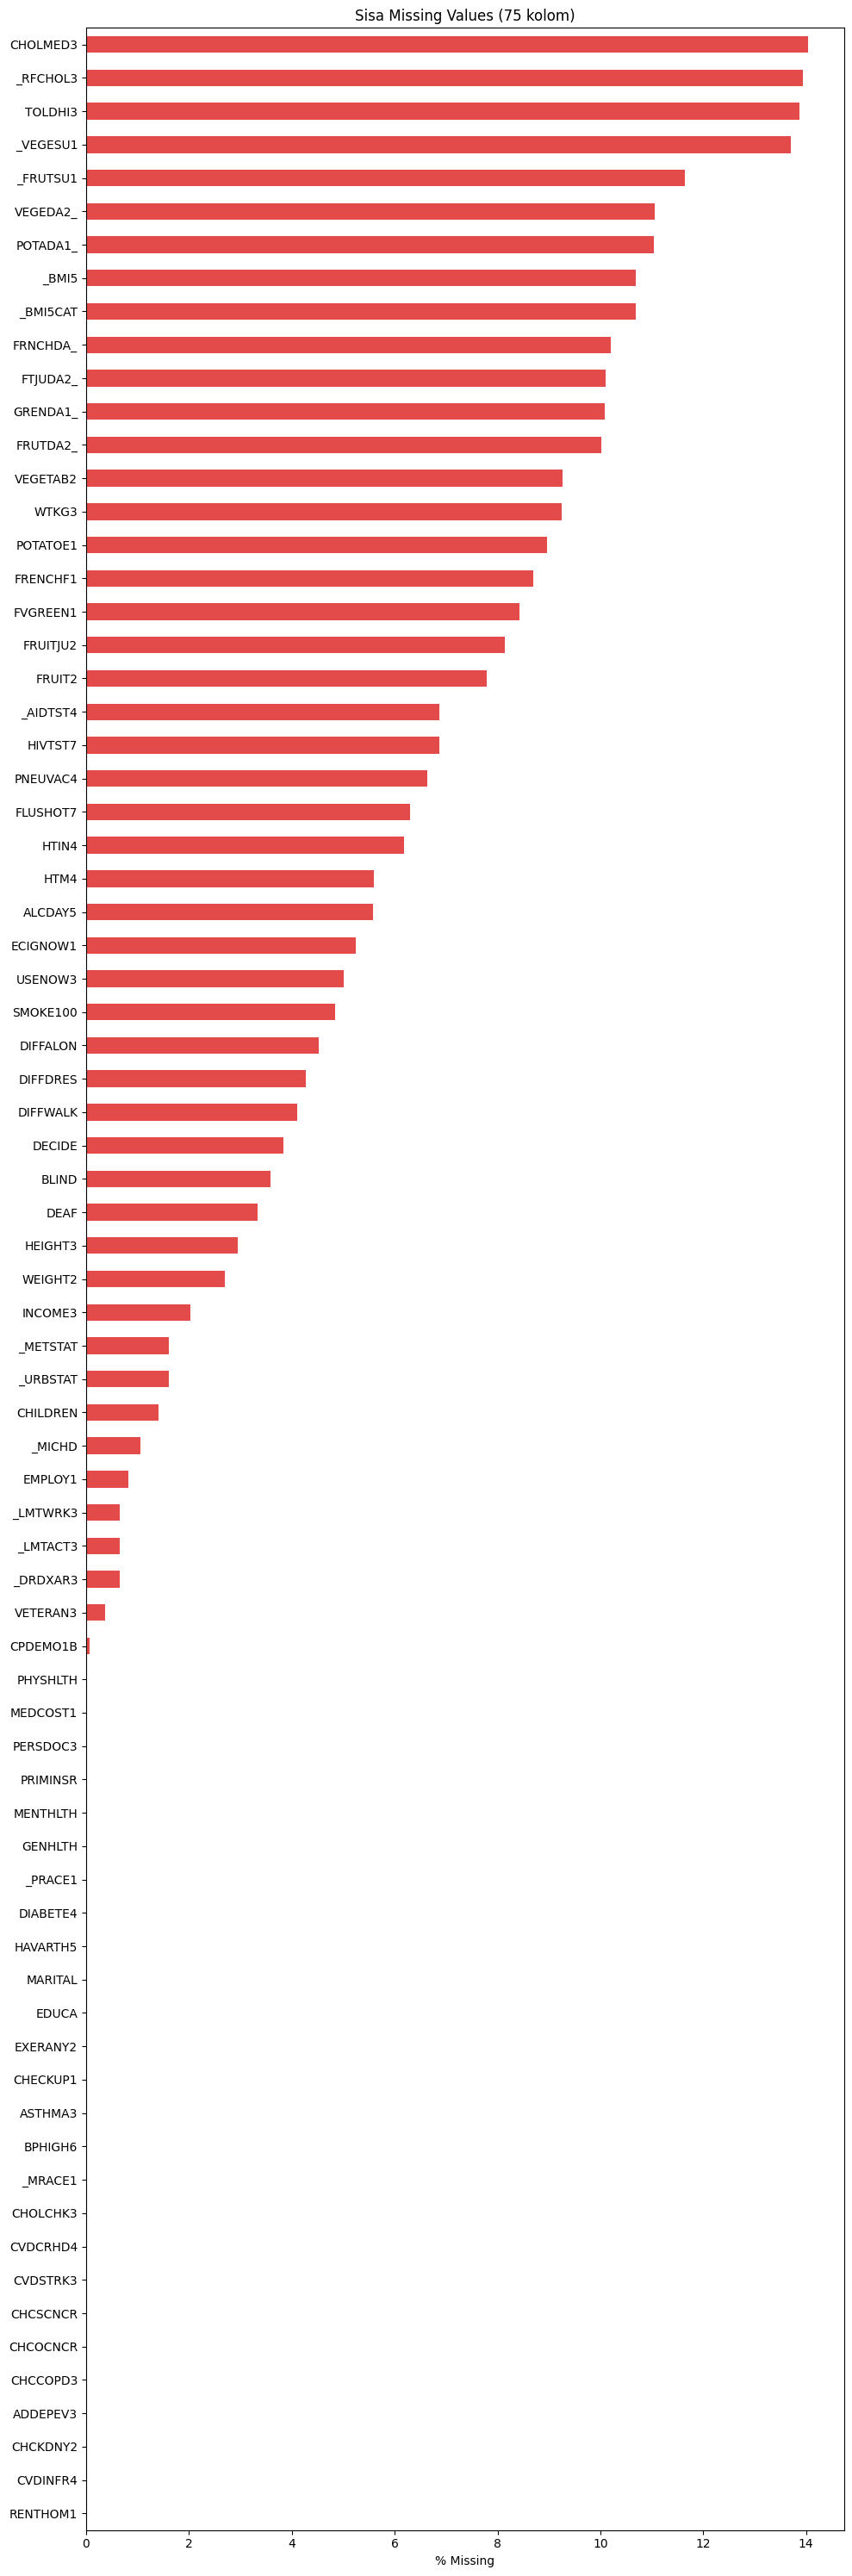

In [213]:
# =============================================================
# 4. CEK SISA MISSING VALUES
# =============================================================
null_summary = pd.DataFrame({
    'null_count':   data1.isnull().sum(),
    'null_percent': (data1.isnull().sum() / len(data1) * 100).round(2),
    'dtype':        data1.dtypes
}).sort_values('null_percent', ascending=False)

has_null = null_summary[null_summary['null_count'] > 0]
print(f"\nKolom dengan sisa null: {len(has_null)} dari {len(data1.columns)} fitur")

if len(has_null) > 0:
    print(has_null.to_string())

    # Visualisasi
    fig, ax = plt.subplots(figsize=(10, max(4, len(has_null) * 0.4)))
    has_null['null_percent'].sort_values().plot(
        kind='barh', ax=ax, color='#E24B4A'
    )
    ax.set_xlabel('% Missing')
    ax.set_title(f'Sisa Missing Values ({len(has_null)} kolom)')
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada missing values tersisa.")

In [214]:
# =============================================================
# 5. RINGKASAN AKHIR
# =============================================================
print("\n========== RINGKASAN ==========")
print(f"Shape awal       : {data.shape}")
print(f"Shape akhir      : {data1.shape}")
print(f"Fitur dihapus    : {data.shape[1] - data1.shape[1]}")
print(f"Fitur tersisa    : {data1.shape[1]}")
print(f"Label distribusi :\n{data1['CVD_LABEL'].value_counts()}")


========== RINGKASAN ==========
Shape awal       : (438693, 304)
Shape akhir      : (438693, 120)
Fitur dihapus    : 184
Fitur tersisa    : 120
Label distribusi :
CVD_LABEL
Healt                391852
Stroke Only           11518
CHD Only              11048
Heart Attack Only     10295
MI + CHD               8285
MI + Stroke            2137
All Three              2114
CHD + Stroke           1444
Name: count, dtype: int64


In [215]:
summary = []
for col in data1.columns:
    summary.append({
        'kolom': col,
        'dtype': data1[col].dtype,
        'n_unik': data1[col].nunique(),
        'missing': data1[col].isnull().sum(),
        'missing_%': round(data1[col].isnull().mean() * 100, 2),
        'nilai_unik': sorted(data1[col].dropna().unique().tolist())
    })

summary_df = pd.DataFrame(summary)

# Tampilkan semua baris dan kolom tanpa terpotong
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
print(summary_df.to_string(index=False))

    kolom   dtype  n_unik  missing  missing_%                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            nilai_unik
   SEXVAR float64       2        0       0.00                                                                                                       

In [216]:
# Cara 1 - Value counts semua kolom sekaligus
for col in data1.columns:
    print(f"\n{'='*50}")
    print(f"Kolom: {col}")
    print(data1[col].value_counts(dropna=False))


Kolom: SEXVAR
SEXVAR
2.0    234883
1.0    203810
Name: count, dtype: int64

Kolom: GENHLTH
GENHLTH
2.0    149112
3.0    137938
1.0     77741
4.0     54736
5.0     18005
7.0       788
9.0       369
NaN         4
Name: count, dtype: int64

Kolom: PHYSHLTH
PHYSHLTH
88.0    287796
30.0     29732
2.0      22220
1.0      17063
3.0      12868
5.0      11642
10.0      8595
77.0      7898
15.0      7623
4.0       6821
7.0       6695
20.0      4670
14.0      3994
6.0       1901
25.0      1866
99.0      1593
8.0       1254
21.0       927
12.0       813
28.0       671
9.0        302
29.0       279
18.0       253
16.0       222
17.0       158
27.0       155
13.0       126
22.0       120
11.0       119
26.0       108
24.0        98
23.0        65
19.0        43
NaN          3
Name: count, dtype: int64

Kolom: MENTHLTH
MENTHLTH
88.0    271161
30.0     24953
2.0      22717
5.0      19130
3.0      14567
10.0     14554
15.0     13475
1.0      13091
20.0      7993
7.0       7428
4.0       7419
77.0     

In [217]:
data1['GENHLTH'] = data1['GENHLTH'].replace({7: np.nan, 9: np.nan})
# 1. Replace kode ambiguous → NaN
data1['MENTHLTH'] = data1['MENTHLTH'].replace({77: np.nan, 99: np.nan})

# 2. Replace 88 (None) → 0
data1['MENTHLTH'] = data1['MENTHLTH'].replace({88: 0})

# 3. Cek hasil
print(data1['MENTHLTH'].value_counts(dropna=False).sort_index())
print(f"\nRange nilai: {data1['MENTHLTH'].min()} - {data1['MENTHLTH'].max()}")
print(f"Missing    : {data1['MENTHLTH'].isna().sum():,}")

# 1. Replace ambiguous → NaN
data1['PHYSHLTH'] = data1['PHYSHLTH'].replace({77: np.nan, 99: np.nan})

# 2. Replace 88 (None) → 0
data1['PHYSHLTH'] = data1['PHYSHLTH'].replace({88: 0})

# 3. Cek hasil
print(data1['PHYSHLTH'].value_counts(dropna=False).sort_index())
print(f"\nRange nilai : {data1['PHYSHLTH'].min()} - {data1['PHYSHLTH'].max()}")
print(f"Missing     : {data1['PHYSHLTH'].isna().sum():,}")



MENTHLTH
0.0     271161
1.0      13091
2.0      22717
3.0      14567
4.0       7419
5.0      19130
6.0       2227
7.0       7428
8.0       1565
9.0        252
10.0     14554
11.0       134
12.0      1082
13.0       160
14.0      2722
15.0     13475
16.0       230
17.0       198
18.0       289
19.0        27
20.0      7993
21.0       516
22.0       159
23.0       102
24.0       128
25.0      2954
26.0       116
27.0       208
28.0       819
29.0       400
30.0     24953
NaN       7917
Name: count, dtype: int64

Range nilai: 0.0 - 30.0
Missing    : 7,917
PHYSHLTH
0.0     287796
1.0      17063
2.0      22220
3.0      12868
4.0       6821
5.0      11642
6.0       1901
7.0       6695
8.0       1254
9.0        302
10.0      8595
11.0       119
12.0       813
13.0       126
14.0      3994
15.0      7623
16.0       222
17.0       158
18.0       253
19.0        43
20.0      4670
21.0       927
22.0       120
23.0        65
24.0        98
25.0      1866
26.0       108
27.0       155
28.0       6

### analisis fitur

In [218]:
# 1 = Underweight
# 2 = Normal Weight
# 3 = Overweight
# 4 = Obese
data1['_BMI5CAT'].value_counts()

_BMI5CAT
3.0    138760
4.0    131305
2.0    115489
1.0      6287
Name: count, dtype: int64

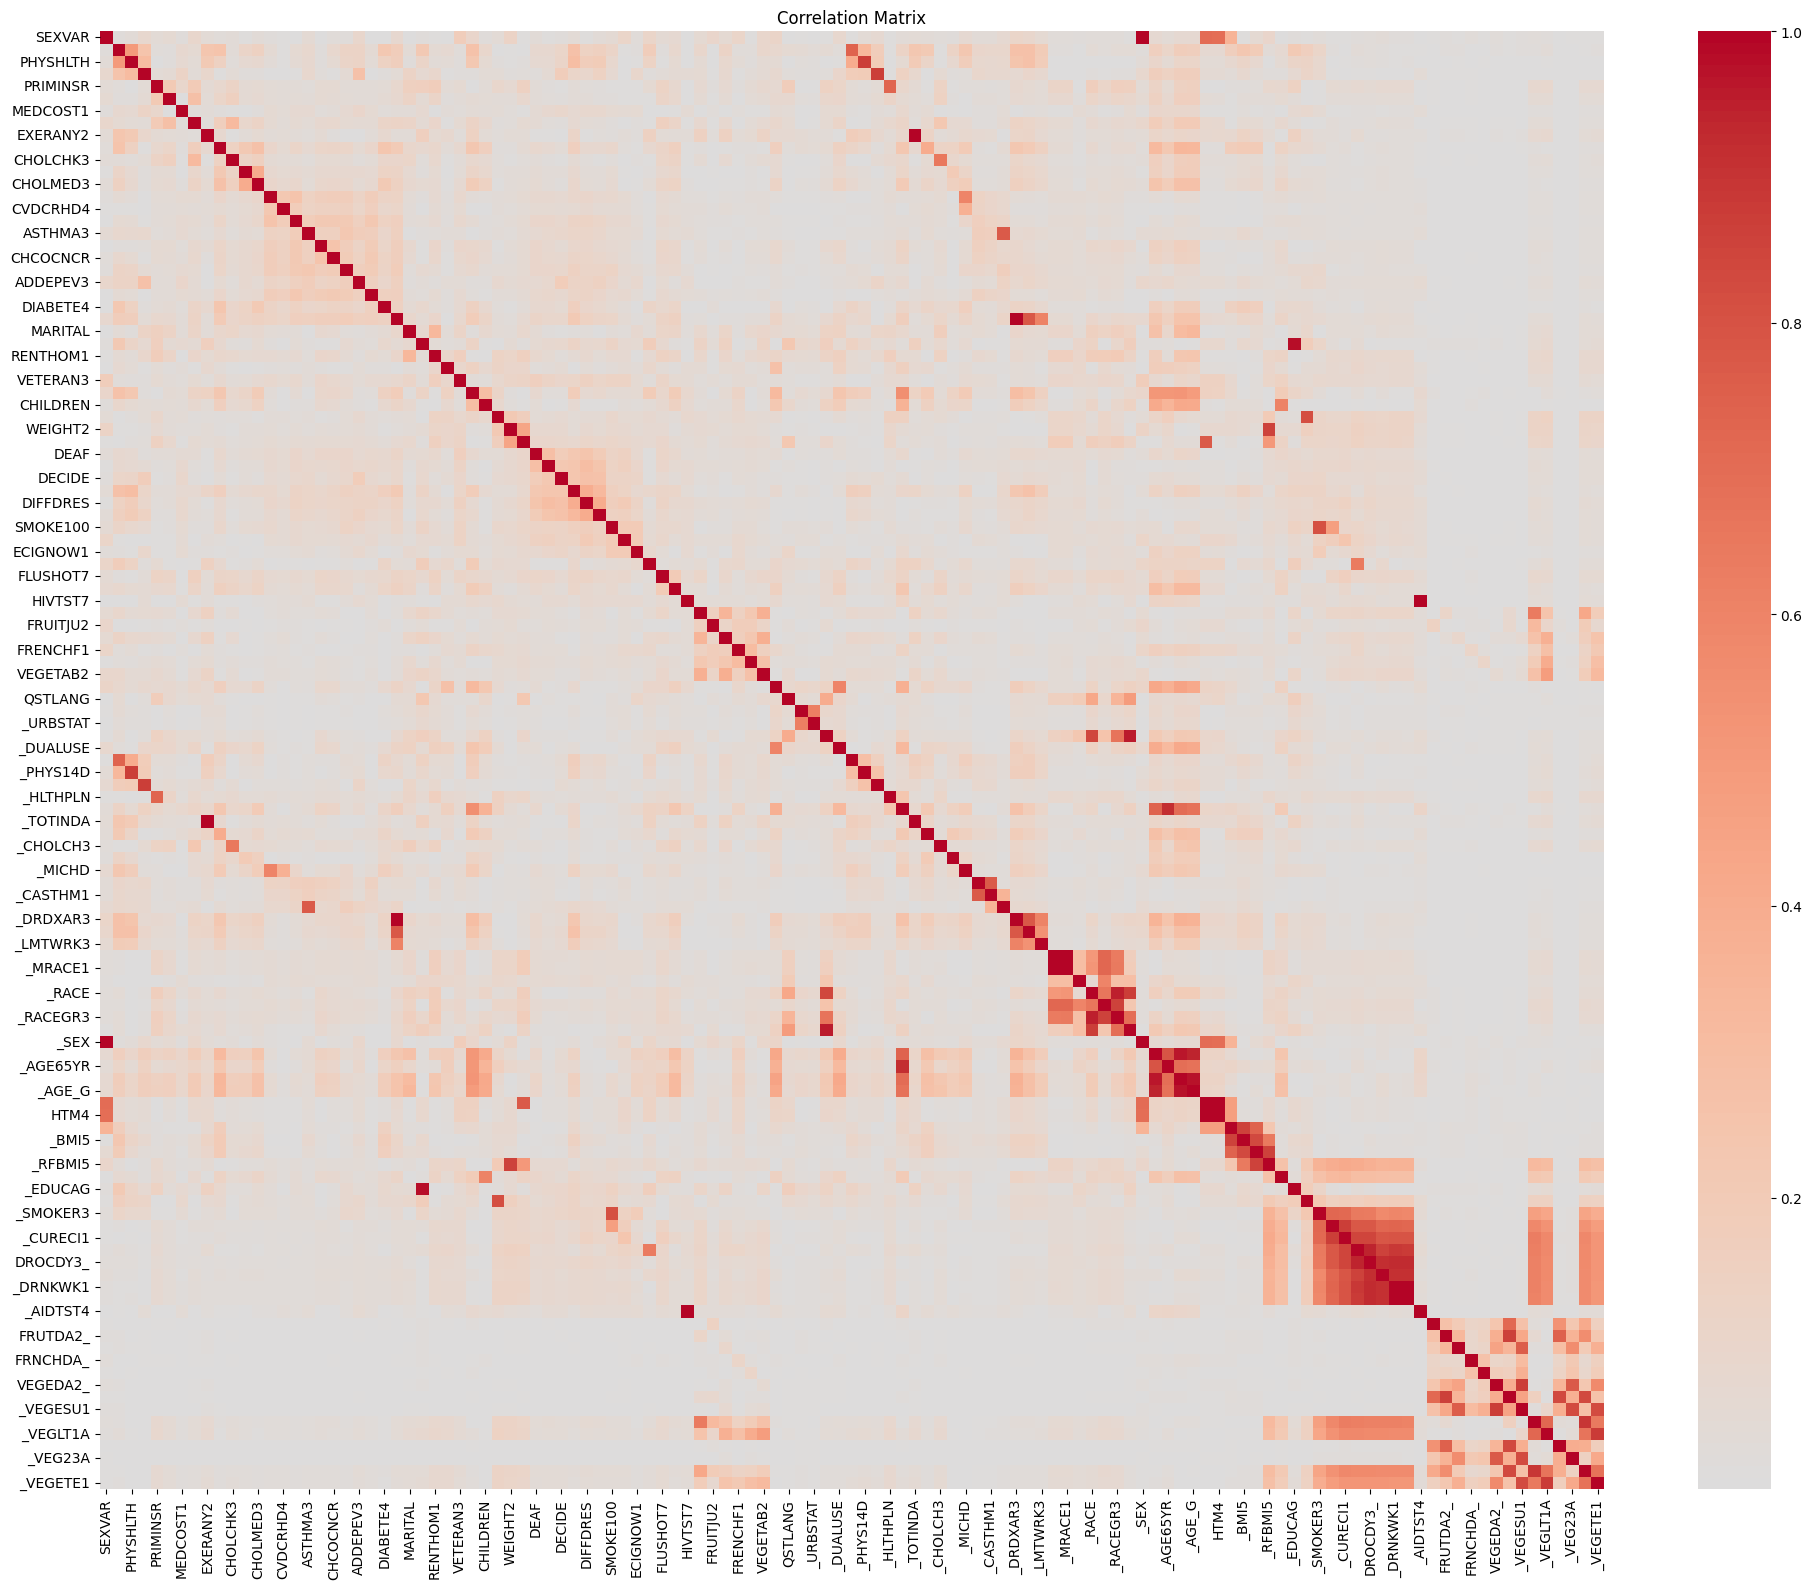

In [219]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung korelasi
corr_matrix = data1.select_dtypes(include='float64').corr().abs()

# Visualisasi heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, 
            cmap='coolwarm',
            center=0,
            annot=False,  # ganti True kalau mau lihat angkanya (lambat kalau banyak fitur)
            fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [220]:
# Tampilkan pasangan fitur dengan korelasi > 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns 
             for row in upper.index 
             if upper.loc[row, col] > 0.70]

high_corr_df = pd.DataFrame(high_corr, columns=['Fitur_1', 'Fitur_2', 'Korelasi'])
high_corr_df = high_corr_df.sort_values('Korelasi', ascending=False)

print(f"Pasangan fitur dengan korelasi > 0.85: {len(high_corr_df)}")
print(high_corr_df.to_string(index=False))

Pasangan fitur dengan korelasi > 0.85: 73
 Fitur_1  Fitur_2  Korelasi
_DRDXAR3 HAVARTH5  1.000000
    HTM4    HTIN4  0.999627
 _MRACE1  _PRACE1  0.999029
    _SEX   SEXVAR  0.997810
_RFDRHV7 _DRNKWK1  0.996025
_AIDTST4  HIVTST7  0.993446
_TOTINDA EXERANY2  0.992476
 _EDUCAG    EDUCA  0.979121
  _AGE_G   _AGE80  0.973881
  _AGE80 _AGEG5YR  0.961100
_RACEPRV _IMPRACE  0.960878
_RACEGR3    _RACE  0.951210
DROCDY3_ DRNKANY5  0.940350
  _AGE_G _AGEG5YR  0.939260
_DRNKWK1 DROCDY3_  0.928625
_RFDRHV7 DROCDY3_  0.928422
_RFBING5 DROCDY3_  0.920074
_AGE65YR _HCVU652  0.914799
_RFDRHV7 _RFBING5  0.912864
_DRNKWK1 _RFBING5  0.910840
_FRUITE1 _FRTLT1A  0.893178
_DRNKWK1 DRNKANY5  0.884059
_VEGETE1 _VEGLT1A  0.882605
_RFDRHV7 DRNKANY5  0.875737
_VEGESU1 VEGEDA2_  0.873527
_CURECI1 _RFSMOK3  0.873298
_MENT14D MENTHLTH  0.872340
_RACEPRV    _RACE  0.871544
_PHYS14D PHYSHLTH  0.870201
_FRUTSU1 FRUTDA2_  0.864627
   _BMI5    WTKG3  0.858912
_RFBING5 DRNKANY5  0.857365
 _RFBMI5  WEIGHT2  0.854933
 _RFBM

In [221]:
# Pastikan nilainya sama
mismatch = data1[data1['SEXVAR'] != data1['_SEX']]
print(f"Baris tidak konsisten: {len(mismatch)}")

# Jika 0 → keduanya identik, cukup pakai SEXVAR, drop _SEX
# Jika ada → perlu investigasi lebih lanjut

Baris tidak konsisten: 478


In [222]:
print("SEXVAR missing:", data1['SEXVAR'].isnull().sum())
print("_SEX missing:", data1['_SEX'].isnull().sum())
print("Baris tidak konsisten:", len(data1[data1['SEXVAR'] != data1['_SEX']]))

SEXVAR missing: 0
_SEX missing: 0
Baris tidak konsisten: 478


In [223]:
# Lihat pola ketidakkonsistenannya
mismatch = data1[data1['SEXVAR'] != data1['_SEX']]
print(mismatch[['SEXVAR', '_SEX']].value_counts())

SEXVAR  _SEX
1.0     2.0     264
2.0     1.0     214
Name: count, dtype: int64


In [224]:
# Bersihkan missing values
if '_DRNKWK1' in data1.columns:
    data1['_DRNKWK1'] = data1['_DRNKWK1'].replace(99900, np.nan)

if '_RFDRHV7' in data1.columns:
    data1['_RFDRHV7'] = data1['_RFDRHV7'].replace(9, np.nan)

print(data1['_DRNKWK1'].value_counts(dropna=False))
print(data1['_RFDRHV7'].value_counts(dropna=False))

_DRNKWK1
5.397605e-79    198343
NaN              34993
2.300000e+01     22090
4.700000e+01     17505
9.300000e+01     13361
7.000000e+02     11771
1.000000e+02      8947
2.000000e+02      8811
1.400000e+03      8409
7.000000e+01      8335
1.400000e+02      7661
2.330000e+02      7537
4.000000e+02      7232
4.670000e+02      7054
6.000000e+02      5352
1.870000e+02      5347
1.170000e+02      5052
3.000000e+02      4733
3.500000e+02      4579
2.800000e+02      4423
9.330000e+02      3424
2.100000e+03      3259
3.730000e+02      2502
8.000000e+02      2232
2.100000e+02      2196
5.000000e+02      2067
5.600000e+02      1967
1.200000e+03      1922
1.000000e+03      1802
5.830000e+02      1658
9.000000e+02      1619
2.800000e+03      1573
1.167000e+03      1569
3.270000e+02      1228
1.630000e+02      1085
4.200000e+02      1076
1.050000e+03      1041
4.200000e+03       967
3.500000e+03       950
1.500000e+03       766
6.530000e+02       743
1.750000e+03       690
8.400000e+02       639
4.

In [225]:
# Cek korelasi dengan _RFCHOL3
print(data1[['_CHOLCH3', '_RFCHOL3']].corr())

# Jika tinggi → pilih salah satu saja
# Rekomendasi: pakai _RFCHOL3 (lebih langsung ke outcome)
#              drop _CHOLCH3 untuk menghindari multikolinearitas

          _CHOLCH3  _RFCHOL3
_CHOLCH3  1.000000 -0.047856
_RFCHOL3 -0.047856  1.000000


In [226]:
cols_to_drop = {
    'Jenis Kelamin'     : ['SEXVAR', 'CELLSEX'],
    'Tinggi/Berat Badan': ['HTIN4', 'HEIGHT3', 'WEIGHT2', '_RFBMI5'],
    'Artritis'          : ['HAVARTH5'],
    'Ras'               : ['_IMPRACE', '_PRACE1', '_RACEG21'],
    'Usia'              : ['_AGE_G', '_AGE65YR'],
    'Alkohol'           : ['DROCDY3_', '_RFBING5'],
    'Buah'              : ['_FRT16A'],
    'Rokok'             : ['USENOW3', 'ECIGNOW1'],
    'Makanan'           : ['POTADA1_', 'GRENDA1_'],
    'Kolesterol'        : ['_CHOLCH3'],
    'Asuransi'          : ['PRIMINSR'],
}

# Flatten semua kolom
all_cols_to_drop = [col for cols in cols_to_drop.values() for col in cols]

# Hapus duplikat
all_cols_to_drop = list(set(all_cols_to_drop))

# Hapus hanya yang ada di dataframe
cols_exist = [c for c in all_cols_to_drop if c in data1.columns]
cols_not_found = [c for c in all_cols_to_drop if c not in data1.columns]

data1 = data1.drop(columns=cols_exist)

# Ringkasan
print("="*50)
for category, cols in cols_to_drop.items():
    dropped = [c for c in cols if c in cols_exist]
    not_found = [c for c in cols if c in cols_not_found]
    print(f"\n{category}:")
    print(f"  ✅ Dihapus    : {dropped}")
    if not_found:
        print(f"  ❌ Tidak ada  : {not_found}")

print("\n" + "="*50)
print(f"Total dihapus : {len(cols_exist)}")
print(f"Tidak ditemukan: {len(cols_not_found)} → {cols_not_found}")
print(f"Fitur tersisa : {data1.shape[1]}")


Jenis Kelamin:
  ✅ Dihapus    : ['SEXVAR']
  ❌ Tidak ada  : ['CELLSEX']

Tinggi/Berat Badan:
  ✅ Dihapus    : ['HTIN4', 'HEIGHT3', 'WEIGHT2', '_RFBMI5']

Artritis:
  ✅ Dihapus    : ['HAVARTH5']

Ras:
  ✅ Dihapus    : ['_IMPRACE', '_PRACE1', '_RACEG21']

Usia:
  ✅ Dihapus    : ['_AGE_G', '_AGE65YR']

Alkohol:
  ✅ Dihapus    : ['DROCDY3_', '_RFBING5']

Buah:
  ✅ Dihapus    : ['_FRT16A']

Rokok:
  ✅ Dihapus    : ['USENOW3', 'ECIGNOW1']

Makanan:
  ✅ Dihapus    : ['POTADA1_', 'GRENDA1_']

Kolesterol:
  ✅ Dihapus    : ['_CHOLCH3']

Asuransi:
  ✅ Dihapus    : ['PRIMINSR']

Total dihapus : 20
Tidak ditemukan: 1 → ['CELLSEX']
Fitur tersisa : 100


### Hapus baris null


Kolom dengan sisa null: 67 dari 100 fitur
          null_count  null_percent    dtype
CHOLMED3       61571         14.04  float64
_RFCHOL3       61151         13.94  float64
TOLDHI3        60836         13.87  float64
_VEGESU1       60127         13.71  float64
_FRUTSU1       51087         11.65  float64
VEGEDA2_       48528         11.06  float64
_BMI5CAT       46852         10.68  float64
_BMI5          46852         10.68  float64
FRNCHDA_       44765         10.20  float64
FTJUDA2_       44349         10.11  float64
FRUTDA2_       43951         10.02  float64
VEGETAB2       40615          9.26  float64
WTKG3          40588          9.25  float64
POTATOE1       39306          8.96  float64
FRENCHF1       38111          8.69  float64
FVGREEN1       36995          8.43  float64
FRUITJU2       35762          8.15  float64
_RFDRHV7       34993          7.98  float64
_DRNKWK1       34993          7.98  float64
FRUIT2         34175          7.79  float64
_AIDTST4       30151          6.8

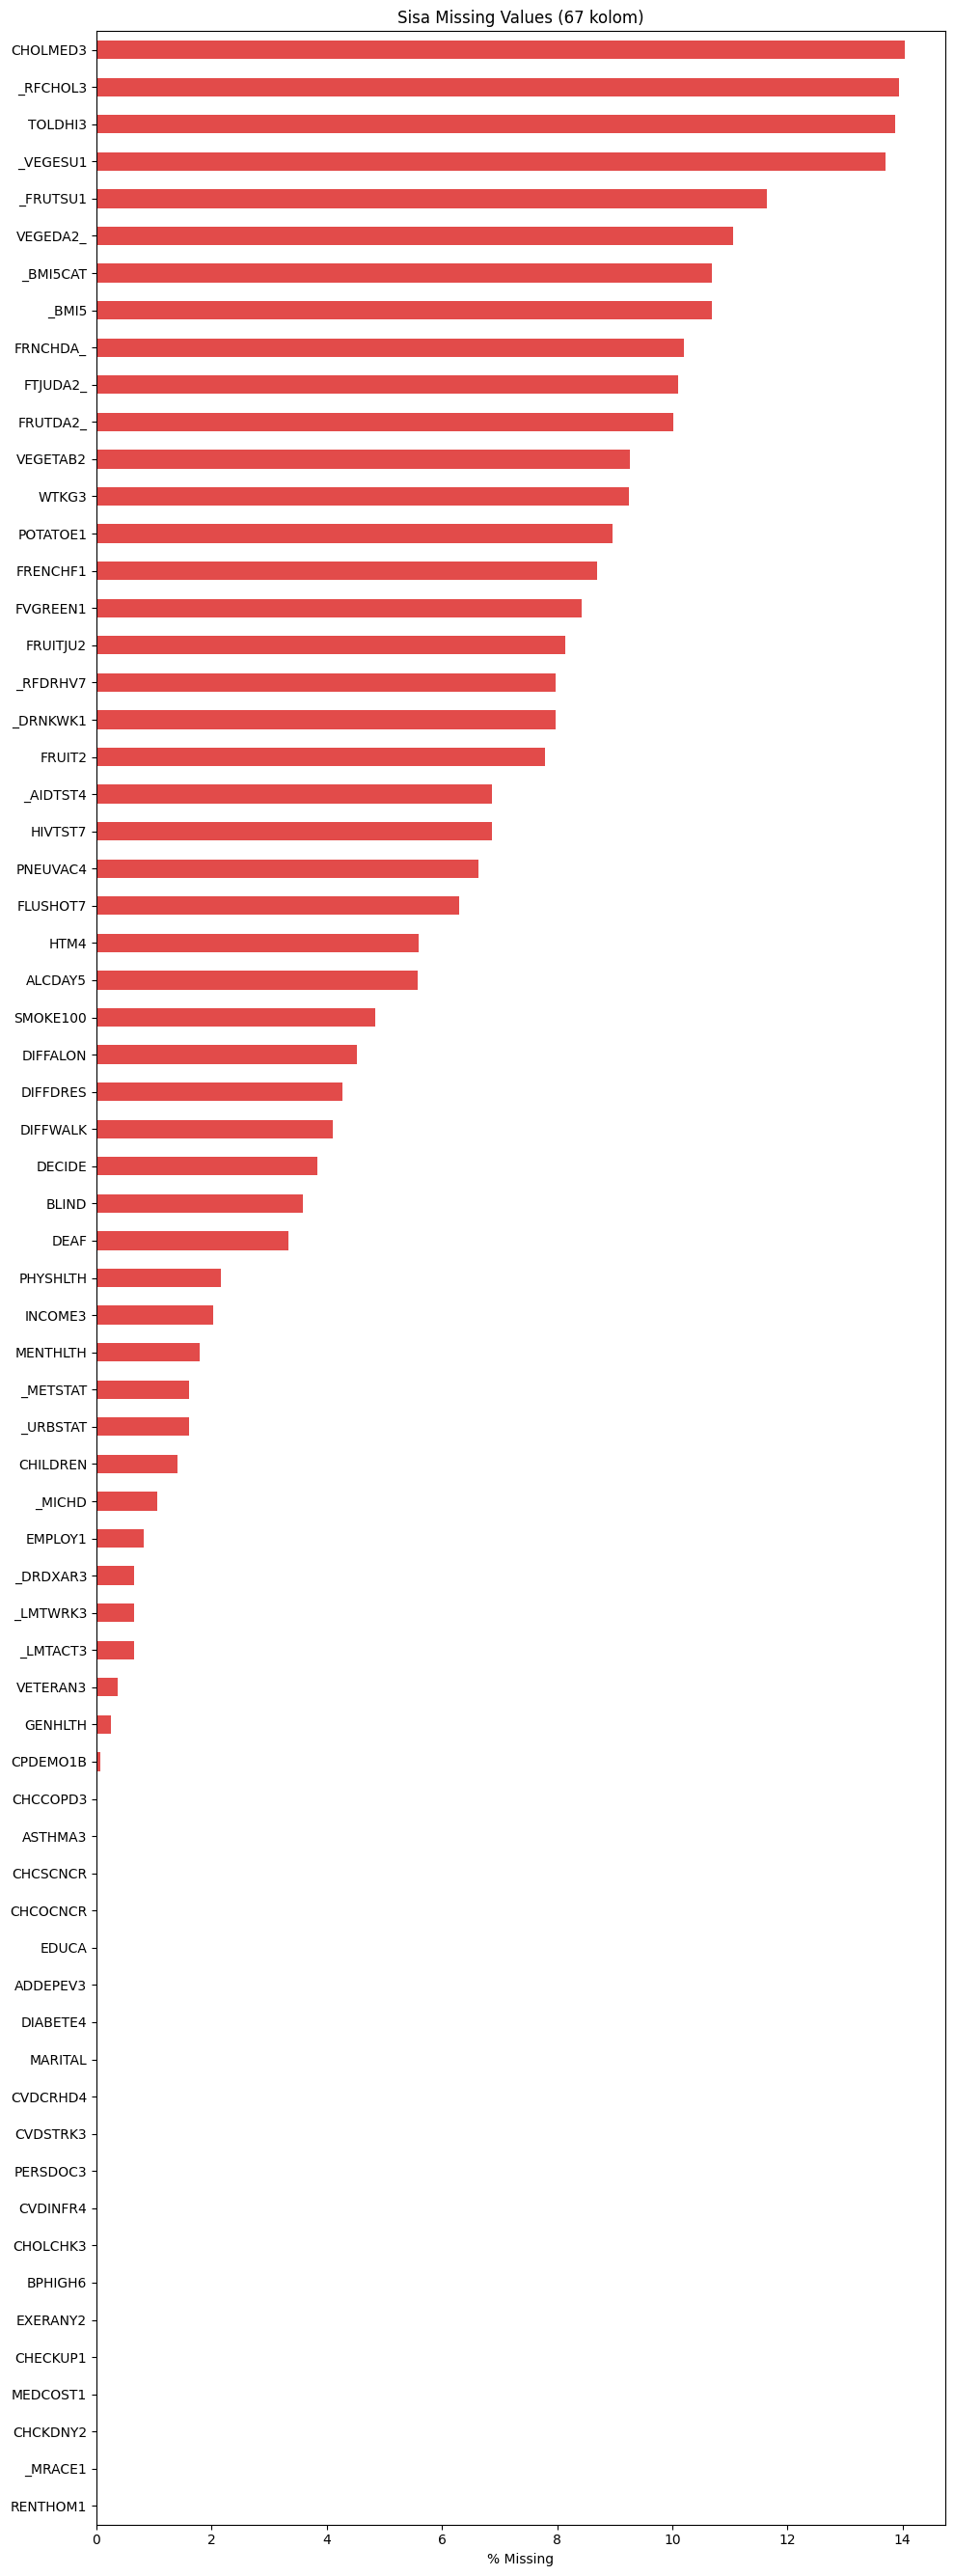

In [227]:
# =============================================================
# 4. CEK SISA MISSING VALUES
# =============================================================
null_summary = pd.DataFrame({
    'null_count':   data1.isnull().sum(),
    'null_percent': (data1.isnull().sum() / len(data1) * 100).round(2),
    'dtype':        data1.dtypes
}).sort_values('null_percent', ascending=False)

has_null = null_summary[null_summary['null_count'] > 0]
print(f"\nKolom dengan sisa null: {len(has_null)} dari {len(data1.columns)} fitur")

if len(has_null) > 0:
    print(has_null.to_string())

    # Visualisasi
    fig, ax = plt.subplots(figsize=(10, max(4, len(has_null) * 0.4)))
    has_null['null_percent'].sort_values().plot(
        kind='barh', ax=ax, color='#E24B4A'
    )
    ax.set_xlabel('% Missing')
    ax.set_title(f'Sisa Missing Values ({len(has_null)} kolom)')
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada missing values tersisa.")

In [228]:
data_new = data1.dropna()
print(f"Sebelum : {len(data1)} baris")
print(f"Sesudah : {len(data_new)} baris")
print(f"Terhapus: {len(data1) - len(data_new)} baris")

Sebelum : 438693 baris
Sesudah : 279995 baris
Terhapus: 158698 baris


In [229]:
severity_map = {
    'Healt'            : 0,  # Sehat
    'Stroke Only'       : 1,  # Level 1 → 1 kondisi
    'CHD Only'          : 1,  # Level 1 → 1 kondisi
    'Heart Attack Only' : 1,  # Level 1 → 1 kondisi
    'MI + CHD'          : 1,  # Level 2 → 2 kondisi
    'MI + Stroke'       : 1,  # Level 2 → 2 kondisi
    'CHD + Stroke'      : 1,  # Level 2 → 2 kondisi
    'All Three'         : 1,  # Level 3 → 3 kondisi
}

data_new['CVD_SEVERITY'] = data_new['CVD_LABEL'].map(severity_map)

# Verifikasi
print(data_new['CVD_SEVERITY'].value_counts())
print(f"\nTotal : {len(data1):,}")

CVD_SEVERITY
0    247671
1     32324
Name: count, dtype: int64

Total : 438,693


/var/folders/c1/0skxdwdx0zdcpl8hlxr2xcz40000gn/T/ipykernel_9459/3809909556.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_new['CVD_SEVERITY'] = data_new['CVD_LABEL'].map(severity_map)


In [230]:
# Pastikan semua kolom ini tidak ada
forbidden = ['_MICHD', 'CVDSTRK3', 'CVDCRHD4', 'CVDINFR4','CVD_LABEL']
data_new = data_new.drop(columns=forbidden)
for col in forbidden:
    if col in data_new.columns:
        print(f"⚠️  MASIH ADA: {col}")
    else:
        print(f"✅ Sudah dihapus: {col}")

✅ Sudah dihapus: _MICHD
✅ Sudah dihapus: CVDSTRK3
✅ Sudah dihapus: CVDCRHD4
✅ Sudah dihapus: CVDINFR4
✅ Sudah dihapus: CVD_LABEL


In [231]:
X = data_new.drop(columns=['CVD_SEVERITY'])
y = data_new['CVD_SEVERITY']

In [232]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [233]:
# ── 1. CEK kolom yang bermasalah ──────────────────────────────────────────────
print(X.dtypes)
print("\nKolom non-numerik:", X.select_dtypes(include=['object', 'category']).columns.tolist())

GENHLTH     float64
PHYSHLTH    float64
MENTHLTH    float64
PERSDOC3    float64
MEDCOST1    float64
CHECKUP1    float64
EXERANY2    float64
BPHIGH6     float64
CHOLCHK3    float64
TOLDHI3     float64
CHOLMED3    float64
ASTHMA3     float64
CHCSCNCR    float64
CHCOCNCR    float64
CHCCOPD3    float64
ADDEPEV3    float64
CHCKDNY2    float64
DIABETE4    float64
MARITAL     float64
EDUCA       float64
RENTHOM1    float64
CPDEMO1B    float64
VETERAN3    float64
EMPLOY1     float64
CHILDREN    float64
INCOME3     float64
DEAF        float64
BLIND       float64
DECIDE      float64
DIFFWALK    float64
DIFFDRES    float64
DIFFALON    float64
SMOKE100    float64
ALCDAY5     float64
FLUSHOT7    float64
PNEUVAC4    float64
HIVTST7     float64
FRUIT2      float64
FRUITJU2    float64
FVGREEN1    float64
FRENCHF1    float64
POTATOE1    float64
VEGETAB2    float64
QSTVER      float64
QSTLANG     float64
_METSTAT    float64
_URBSTAT    float64
_DUALUSE    float64
_RFHLTH     float64
_PHYS14D    float64


In [234]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Pilih salah satu scaler sesuai kebutuhan
# 2. MinMaxScaler - range [0,1] (cocok untuk data tanpa outlier)
scaler = MinMaxScaler()
# Fit pada train, transform pada train & test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # ⚠️ Hanya transform, bukan fit_transform!

Class distribution → Sehat: 198137, CVD: 25859
scale_pos_weight   : 7.6622

     PERFORMANCE MEASURES (Binary Classification)
  Balanced Accuracy  : 0.7752  ← METRIC UTAMA
  Macro-Recall       : 0.7752  ← METRIC UTAMA
  AUC-ROC            : 0.8520
-------------------------------------------------------
  F1-Score Macro     : 0.6382
  F1-Score Weighted  : 0.7973
  F1-Score CVD       : 0.4312
-------------------------------------------------------
  Sensitivity (CVD  ) : 0.7995
  Specificity (Sehat) : 0.7509

  TP: 5169 | TN: 37195 | FP: 12339 ← False Alarm | FN: 1296 ← Berbahaya!

Classification Report:
              precision    recall  f1-score   support

   Sehat (0)       0.97      0.75      0.85     49534
     CVD (1)       0.30      0.80      0.43      6465

    accuracy                           0.76     55999
   macro avg       0.63      0.78      0.64     55999
weighted avg       0.89      0.76      0.80     55999



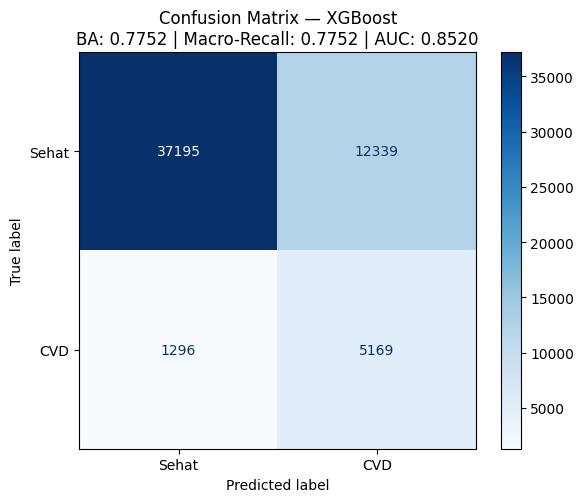

In [236]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, balanced_accuracy_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np


def train_evaluate_xgb(X_train, X_test, y_train, y_test,
                        n_estimators=100, max_depth=6, learning_rate=0.1,
                        label_names=('Sehat', 'CVD')):
    """
    Train XGBClassifier dan evaluasi lengkap dengan performance measures.

    Parameters
    ----------
    X_train, X_test : array-like  — fitur train/test
    y_train, y_test : array-like  — label train/test (binary 0/1)
    n_estimators    : int         — jumlah pohon (default 100)
    max_depth       : int         — kedalaman pohon (default 6)
    learning_rate   : float       — learning rate (default 0.1)
    label_names     : tuple       — nama kelas (default: Sehat, CVD)

    Returns
    -------
    dict berisi model dan semua metric
    """

    # ── 1. CLASS IMBALANCE ────────────────────────────────────────────────────
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"Class distribution → {label_names[0]}: {(y_train==0).sum()}, "
          f"{label_names[1]}: {(y_train==1).sum()}")
    print(f"scale_pos_weight   : {scale_pos_weight:.4f}\n")

    # ── 2. TRAINING ───────────────────────────────────────────────────────────
    model = XGBClassifier(
        n_estimators     = n_estimators,
        max_depth        = max_depth,
        learning_rate    = learning_rate,
        scale_pos_weight = scale_pos_weight,
        eval_metric      = 'logloss',
        random_state     = 42
    )
    model.fit(X_train, y_train)

    # ── 3. PREDIKSI ───────────────────────────────────────────────────────────
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # ── 4. METRICS ────────────────────────────────────────────────────────────
    balanced_acc    = balanced_accuracy_score(y_test, y_pred)
    macro_recall    = recall_score(y_test, y_pred, average='macro')
    auc_roc         = roc_auc_score(y_test, y_prob)
    f1_macro        = f1_score(y_test, y_pred, average='macro')
    f1_weighted     = f1_score(y_test, y_pred, average='weighted')
    f1_positive     = f1_score(y_test, y_pred, pos_label=1)
    recall_per_class = recall_score(y_test, y_pred, average=None)
    sensitivity     = recall_per_class[1]
    specificity     = recall_per_class[0]

    # ── 5. PRINT HASIL ────────────────────────────────────────────────────────
    print("="*55)
    print("     PERFORMANCE MEASURES (Binary Classification)")
    print("="*55)
    print(f"  Balanced Accuracy  : {balanced_acc:.4f}  ← METRIC UTAMA")
    print(f"  Macro-Recall       : {macro_recall:.4f}  ← METRIC UTAMA")
    print(f"  AUC-ROC            : {auc_roc:.4f}")
    print("-"*55)
    print(f"  F1-Score Macro     : {f1_macro:.4f}")
    print(f"  F1-Score Weighted  : {f1_weighted:.4f}")
    print(f"  F1-Score {label_names[1]:<8}  : {f1_positive:.4f}")
    print("-"*55)
    print(f"  Sensitivity ({label_names[1]:<5}) : {sensitivity:.4f}")
    print(f"  Specificity ({label_names[0]:<5}) : {specificity:.4f}")
    print("="*55)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n  TP: {tp} | TN: {tn} | FP: {fp} ← False Alarm | FN: {fn} ← Berbahaya!")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=[f'{label_names[0]} (0)', f'{label_names[1]} (1)']))

    # ── 6. PLOT CONFUSION MATRIX ──────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=list(label_names)).plot(cmap='Blues', ax=ax)
    ax.set_title(f"Confusion Matrix — XGBoost\n"
                 f"BA: {balanced_acc:.4f} | Macro-Recall: {macro_recall:.4f} | AUC: {auc_roc:.4f}")
    plt.tight_layout()
    plt.show()

    # ── 7. RETURN ─────────────────────────────────────────────────────────────
    return {
        'model'           : model,
        'balanced_accuracy': balanced_acc,
        'macro_recall'    : macro_recall,
        'auc_roc'         : auc_roc,
        'f1_macro'        : f1_macro,
        'f1_weighted'     : f1_weighted,
        'f1_positive'     : f1_positive,
        'sensitivity'     : sensitivity,
        'specificity'     : specificity,
        'confusion_matrix': cm,
        'y_pred'          : y_pred,
        'y_prob'          : y_prob,
    }


# ── CARA PAKAI ────────────────────────────────────────────────────────────────
results = train_evaluate_xgb(X_train, X_test, y_train, y_test)

# Akses metric atau model jika perlu
# results['model']
# results['auc_roc']

Class distribution → Sehat: 198137, CVD: 25859
scale_pos_weight   : 7.6622

     PERFORMANCE MEASURES (Binary Classification)
  Balanced Accuracy  : 0.7752  ← METRIC UTAMA
  Macro-Recall       : 0.7752  ← METRIC UTAMA
  AUC-ROC            : 0.8520
-------------------------------------------------------
  F1-Score Macro     : 0.6382
  F1-Score Weighted  : 0.7973
  F1-Score CVD       : 0.4312
-------------------------------------------------------
  Sensitivity (CVD  ) : 0.7995
  Specificity (Sehat) : 0.7509

  TP: 5169 | TN: 37195 | FP: 12339 ← False Alarm | FN: 1296 ← Berbahaya!

Classification Report:
              precision    recall  f1-score   support

   Sehat (0)       0.97      0.75      0.85     49534
     CVD (1)       0.30      0.80      0.43      6465

    accuracy                           0.76     55999
   macro avg       0.63      0.78      0.64     55999
weighted avg       0.89      0.76      0.80     55999



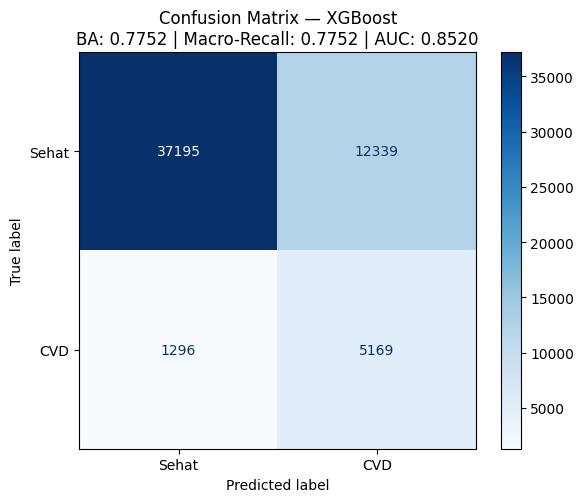

In [237]:
# ── CARA PAKAI ────────────────────────────────────────────────────────────────
results = train_evaluate_xgb(X_train_scaled, X_test_scaled, y_train, y_test)